In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from PIL import Image
from pycocotools.coco import COCO

In [2]:
# ── Dataset registry (Matched to your paths) ──────────────────────────────────
DATASETS = {
    "chai": {
        "json_path": "/caa/Homes01/mburges/datasets/IOD_Datasets/CHAI/annotations/instances_train2017.json",
        "image_folder": "/caa/Homes01/mburges/datasets/IOD_Datasets/CHAI/images",
    },
    "tiny_dota": {
        "json_path": "/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024_tiny_abb.json",
        "image_folder": "/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/images",
    },
    "fmow": {
        "json_path": "/caa/Homes01/mburges/datasets/fMoW/annotations/fmow_coco.json",
        "image_folder": "/caa/Homes01/mburges/datasets/fMoW/images",
    },
    "dota_v2": {
        "json_path": "/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024.json",
        "image_folder": "/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/images",
    }
}

# ── Settings ──────────────────────────────────────────────────────────────────
DATASET_NAME    = "chai" # Recommended: a dataset with dense small objects
SEED            = 47        # Seed for reproducible image selection
GRID_SIZE       = 9         # 5x5 grid for the patches
NUM_AL_PATCHES  = 4         # How many patches the AL framework selects
OVERLAP         = 0.2      # Patch overlap fraction used during tiling (0 = no overlap)
SAVE_PATH       = None      # Set to a path to save the figure, or None to display

# ── Colors & Styling (Slide Optimized) ────────────────────────────────────────
COL_TRADITIONAL = "#ff0000" # Red for the slow, systematic way
COL_AL          = "#3b82f6" # Blue for the smart, AL way
COL_BOX         = "#fbbf24" # Yellow for the FM bounding boxes
FONT_TITLE      = 24
FONT_LABEL      = 24

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Found 3×3 block in '1945_04_20_Graz_37' (top-left 4,1)
Assembled image: 2496×2496 px  |  31 annotations  |  overlap=20%


/tmp/ipykernel_2294015/1296420667.py:211: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle((gx*step, gy*step), step, step,


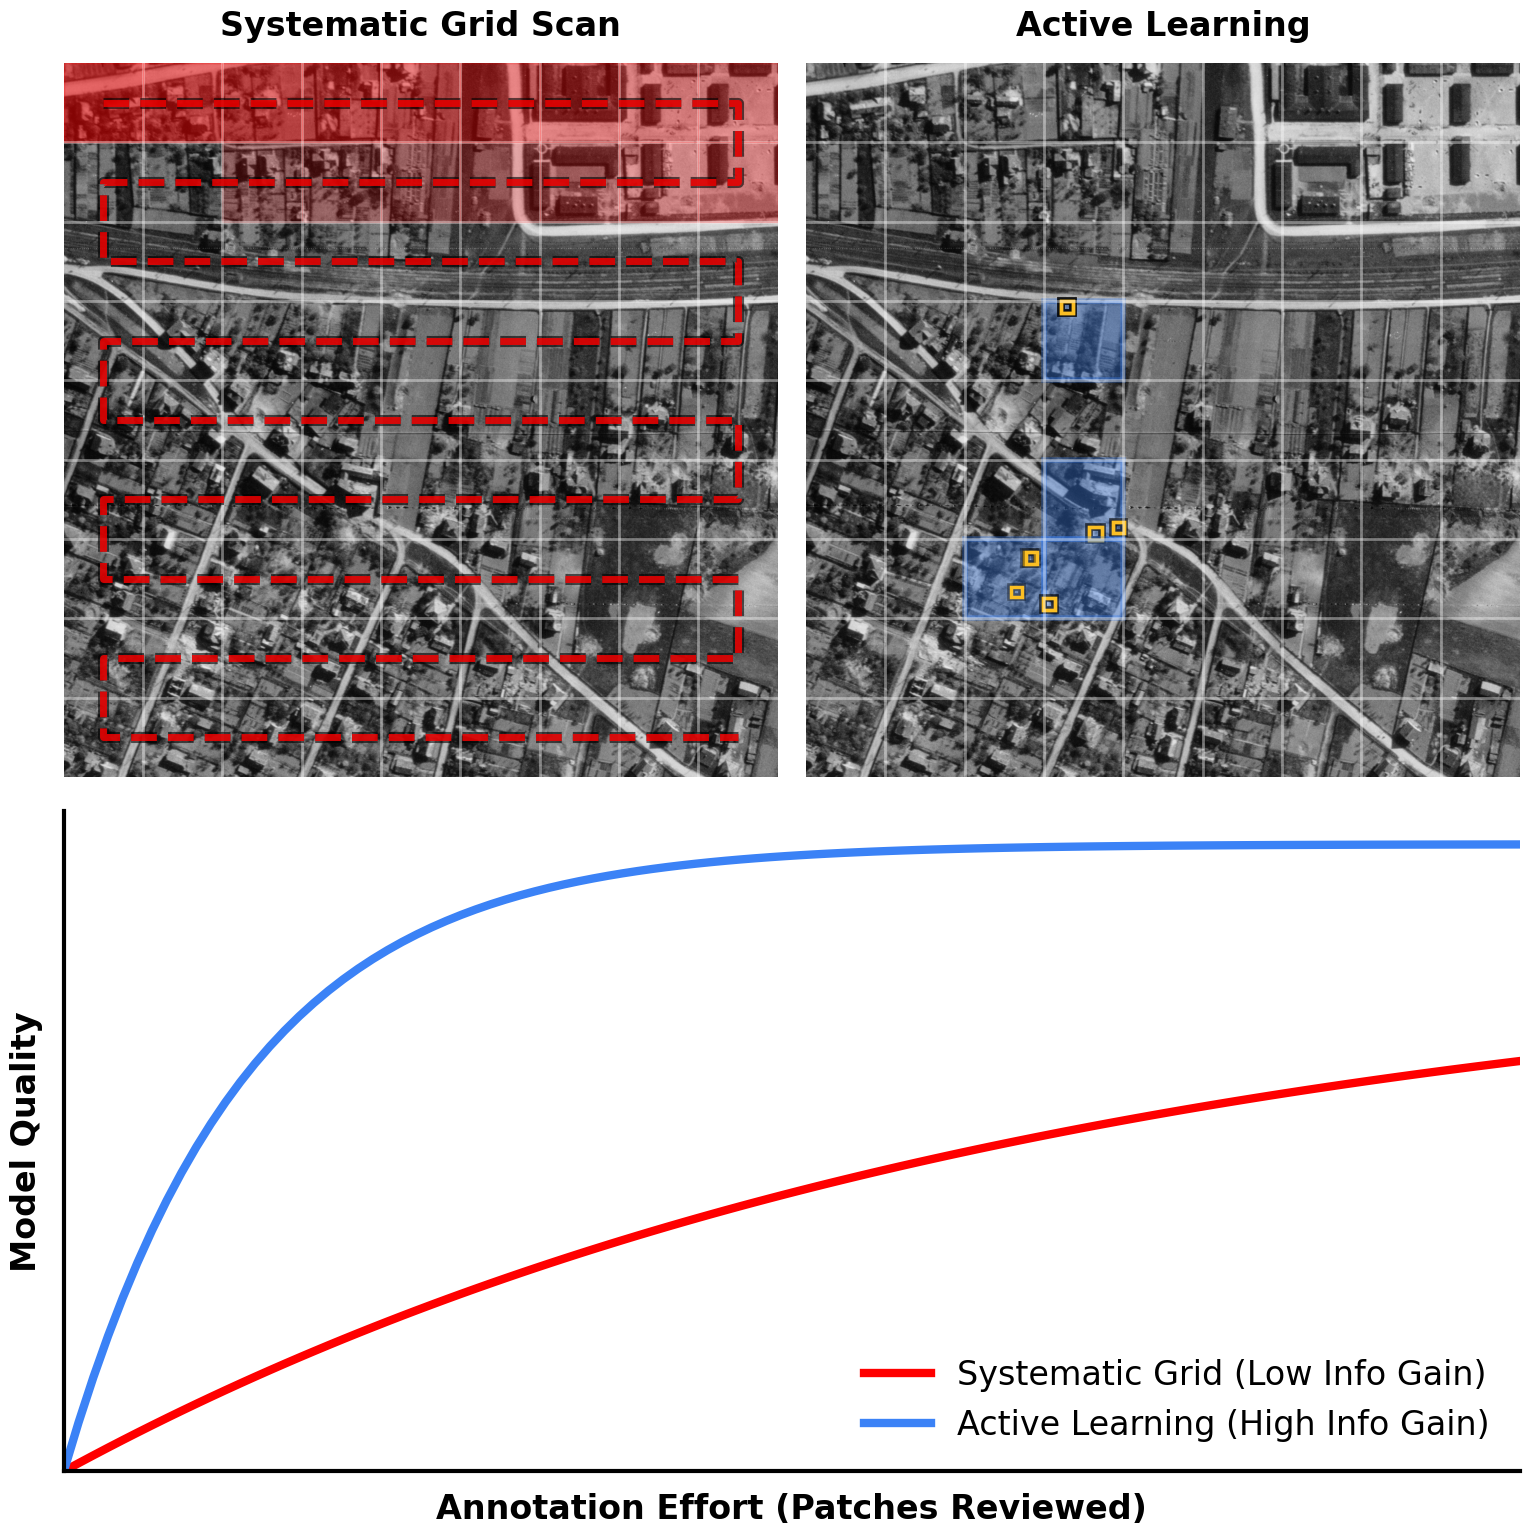

In [3]:
# ── Helper functions ──────────────────────────────────────────────────────────
def parse_patch_name(filename):
    """'base_row_col.ext' → (base, row, col), or (None,None,None) if not patchified."""
    name  = os.path.splitext(os.path.basename(filename))[0]
    parts = name.rsplit('_', 2)
    if len(parts) == 3:
        try:
            return parts[0], int(parts[1]), int(parts[2])
        except ValueError:
            pass
    return None, None, None

def reconstruct_patches(coco, image_folder, overlap=0.0, seed=None):
    """
    Glue patchified tiles back into one image, offset all annotations.
    Tries 3×3 first, then 2×2, then falls back to the densest group.
    Returns (image, annotations, (n_rows, n_cols)).
    Missing tiles (no GT → removed from dataset) are filled with dark grey.
    `overlap` is the fraction of each tile that overlaps with its neighbour.
    """
    if seed is not None:
        random.seed(seed)

    # Group all COCO entries by base image name
    groups = {}
    for img_info in coco.loadImgs(coco.getImgIds()):
        base, c, r = parse_patch_name(img_info['file_name'])
        if base is not None:
            groups.setdefault(base, []).append((r, c, img_info))

    if not groups:
        raise RuntimeError("No patchified images found (expected 'base_row_col.ext' naming).")

    def find_contiguous_corners(patch_list, size):
        """Return all (r,c) that are valid top-left corners of a size×size block."""
        rc_set = {(r, c) for r, c, _ in patch_list}
        return [(r, c) for r, c, _ in patch_list
                if all((r + dr, c + dc) in rc_set
                       for dr in range(size) for dc in range(size))]

    bases = list(groups.keys())
    random.shuffle(bases)

    for target in [3, 2]:
        for base in bases:
            corners = find_contiguous_corners(groups[base], target)
            if corners:
                cr, cc = random.choice(corners)
                block   = {(cr + dr, cc + dc) for dr in range(target) for dc in range(target)}
                tiles   = [(r, c, info) for r, c, info in groups[base] if (r, c) in block]
                print(f"Found {target}×{target} block in '{base}' (top-left {cr},{cc})")
                return _assemble(coco, image_folder, tiles, cr, cc, target, target, overlap)

    # Fallback: the group with the most tiles (might have gaps)
    best = max(groups, key=lambda b: len(groups[b]))
    tiles = groups[best]
    rows  = [r for r, c, _ in tiles]; cols = [c for r, c, _ in tiles]
    nr    = max(rows) - min(rows) + 1;  nc = max(cols) - min(cols) + 1
    print(f"Fallback: {len(tiles)} tiles from '{best}' ({nr}×{nc} extent, may have gaps)")
    return _assemble(coco, image_folder, tiles, min(rows), min(cols), nr, nc, overlap)

def _assemble(coco, image_folder, tiles, min_r, min_c, n_rows, n_cols, overlap=0.0):
    """
    Paste tiles onto a canvas and collect annotations with pixel offsets.

    overlap: fraction of each tile that overlaps with its neighbour (e.g. 0.10).
    The overlapping border pixels are cropped from the *incoming* (left/top) edge
    of each non-edge tile so every pixel appears exactly once in the mosaic.
    Set overlap=0 for gapless patches with no overlap.
    """
    pw, ph = Image.open(os.path.join(image_folder, tiles[0][2]['file_name'])).size

    sx   = round(pw * (1 - overlap))   # horizontal stride in pixels
    sy   = round(ph * (1 - overlap))   # vertical stride in pixels
    ov_x = pw - sx                     # overlap width  in pixels
    ov_y = ph - sy                     # overlap height in pixels

    canvas_w = (n_cols - 1) * sx + pw
    canvas_h = (n_rows - 1) * sy + ph
    canvas   = Image.new('RGB', (canvas_w, canvas_h), (40, 40, 40))

    all_annotations = []
    for r, c, img_info in tiles:
        patch = Image.open(os.path.join(image_folder, img_info['file_name'])).convert('RGB')
        c_idx = c - min_c
        r_idx = r - min_r

        # Crop incoming overlap edge so each pixel is owned by exactly one tile
        skip_x = ov_x if c_idx > 0 else 0
        skip_y = ov_y if r_idx > 0 else 0
        cropped = patch.crop((skip_x, skip_y, pw, ph))

        x_paste = c_idx * sx + skip_x
        y_paste = r_idx * sy + skip_y
        canvas.paste(cropped, (x_paste, y_paste))

        # Annotation coords are relative to the full (uncropped) tile origin
        x_off = c_idx * sx
        y_off = r_idx * sy
        for ann in coco.loadAnns(coco.getAnnIds(imgIds=img_info['id'])):
            new_ann           = dict(ann)
            bx, by, bw, bh    = ann['bbox']
            new_ann['bbox']   = [bx + x_off, by + y_off, bw, bh]
            new_ann['center'] = (bx + bw / 2 + x_off, by + bh / 2 + y_off)
            all_annotations.append(new_ann)

    return canvas, all_annotations, (n_rows, n_cols)

def crop_square(image, annotations):
    w, h = image.size
    side = min(w, h)
    left, top = (w - side) // 2, (h - side) // 2
    image = image.crop((left, top, left + side, top + side))
    adjusted = []
    for ann in annotations:
        x, y, bw, bh = ann["bbox"]
        x -= left; y -= top
        if x + bw > 0 and y + bh > 0 and x < side and y < side:
            x = max(x, 0); y = max(y, 0)
            bw = min(bw, side - x); bh = min(bh, side - y)
            new_ann = dict(ann)
            new_ann["bbox"]   = [x, y, bw, bh]
            new_ann["center"] = (x + bw / 2, y + bh / 2)
            adjusted.append(new_ann)
    return image, adjusted

def outline_pe(lw, color="black", alpha=0.6):
    return [path_effects.Stroke(linewidth=lw+3, foreground=color, alpha=alpha),
            path_effects.Normal()]

# ── Setup Data ────────────────────────────────────────────────────────────────
cfg  = DATASETS[DATASET_NAME]
coco = COCO(cfg["json_path"])
image, annotations, patch_grid = reconstruct_patches(
    coco, cfg["image_folder"], overlap=OVERLAP, seed=SEED)
image, annotations = crop_square(image, annotations)
print(f"Assembled image: {image.size[0]}×{image.size[1]} px  |  "
      f"{len(annotations)} annotations  |  overlap={OVERLAP:.0%}")
side = image.size[0]
step = side / GRID_SIZE

# ── Figure Layout ─────────────────────────────────────────────────────────────
FIG_SIZE = 16
L, R = 0.07, 0.98
T, B = 0.94, 0.06
WS   = 0.04
HS   = 0.05

avail_w = FIG_SIZE * (R - L)
avail_h = FIG_SIZE * (T - B)
img_w   = avail_w / (2 + WS)
img_h   = img_w
bot_h   = avail_h / (1 + HS / 2) - img_h

fig = plt.figure(figsize=(FIG_SIZE, FIG_SIZE), facecolor="#ffffff")
gs  = fig.add_gridspec(
    2, 2,
    height_ratios=[img_h, bot_h],
    left=L, right=R, top=T, bottom=B,
    hspace=HS, wspace=WS,
)

ax_trad = fig.add_subplot(gs[0, 0])
ax_al   = fig.add_subplot(gs[0, 1])
ax_plot = fig.add_subplot(gs[1, :])

for ax in [ax_trad, ax_al]:
    ax.imshow(image)
    ax.set_xlim(0, side)
    ax.set_ylim(side, 0)
    ax.axis("off")
    for i in range(1, GRID_SIZE):
        ax.axhline(i * step, color="white", lw=2, alpha=0.4)
        ax.axvline(i * step, color="white", lw=2, alpha=0.4)

# ── Left Panel: Traditional Systematic Scan ───────────────────────────────────
ax_trad.set_title("Systematic Grid Scan", fontsize=FONT_TITLE, fontweight="bold", pad=20)

centers_x, centers_y = [], []
for row in range(GRID_SIZE):
    y    = row * step + step / 2
    cols = range(GRID_SIZE) if row % 2 == 0 else range(GRID_SIZE - 1, -1, -1)
    for col in cols:
        centers_x.append(col * step + step / 2)
        centers_y.append(y)

ax_trad.plot(centers_x, centers_y, color=COL_TRADITIONAL, linestyle="--", lw=5, alpha=0.8,
             path_effects=outline_pe(5))

N_TRAD = 16
for i in range(N_TRAD):
    alpha = 0.50 - 0.32 * (i / (N_TRAD - 1))
    r, c  = int(centers_y[i] // step), int(centers_x[i] // step)
    rect  = mpatches.Rectangle((c*step, r*step), step, step,
                                fill=True, color=COL_TRADITIONAL, alpha=alpha)
    ax_trad.add_patch(rect)

# ── Right Panel: Active Learning + FM Framework ───────────────────────────────
ax_al.set_title("Active Learning", fontsize=FONT_TITLE, fontweight="bold", pad=20)

cell_counts = {}
for ann in annotations:
    cx, cy = ann["center"]
    gx, gy = int(cx // step), int(cy // step)
    cell_counts[(gx, gy)] = cell_counts.get((gx, gy), 0) + 1

top_cell_coords = [coords for coords, _ in
                   sorted(cell_counts.items(), key=lambda x: x[1], reverse=True)[:NUM_AL_PATCHES]]

for (gx, gy) in top_cell_coords:
    rect = mpatches.Rectangle((gx*step, gy*step), step, step,
                               fill=True, color=COL_AL, alpha=0.35, lw=4, edgecolor=COL_AL)
    ax_al.add_patch(rect)
    for ann in annotations:
        cx, cy = ann["center"]
        if int(cx // step) == gx and int(cy // step) == gy:
            bx, by, bw, bh = ann["bbox"]
            box = mpatches.Rectangle((bx, by), bw, bh, fill=False, edgecolor=COL_BOX, lw=2.5,
                                     path_effects=outline_pe(2.5, "black", 0.4))
            ax_al.add_patch(box)

# ── Bottom Panel: Conceptual Learning Curve ───────────────────────────────────
x      = np.linspace(0, 10, 100)
y_trad = 0.8  * (1 - np.exp(-0.15 * x))
y_al   = 0.95 * (1 - np.exp(-0.8  * x))

ax_plot.plot(x, y_trad, color=COL_TRADITIONAL, lw=6, label="Systematic Grid (Low Info Gain)")
ax_plot.plot(x, y_al,   color=COL_AL,          lw=6, label="Active Learning (High Info Gain)")

ax_plot.set_xlim(0, 10); ax_plot.set_ylim(0, 1)
ax_plot.spines['top'].set_visible(False);   ax_plot.spines['right'].set_visible(False)
ax_plot.spines['left'].set_linewidth(3);    ax_plot.spines['bottom'].set_linewidth(3)
ax_plot.set_xticks([]); ax_plot.set_yticks([])
ax_plot.set_xlabel("Annotation Effort (Patches Reviewed)", fontsize=FONT_TITLE, fontweight="bold", labelpad=15)
ax_plot.set_ylabel("Model Quality",                        fontsize=FONT_TITLE, fontweight="bold", labelpad=15)
ax_plot.legend(loc="lower right", fontsize=FONT_LABEL, frameon=False)

if SAVE_PATH:
    plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")
    print(f"Schematic saved to {SAVE_PATH}")

plt.show()